# Practical 04 — Distance Measures (Euclidean, Manhattan, Cosine)

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Syllabus:** *Implement different distance measures (Euclidean, Manhattan, Cosine) on sample datasets.*  
**Data:** UCI Wine (chemistry) + short-document TF–IDF.

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG (path, features, two row indices)
        ↓
[3] HAND table (L1, L2, L∞, dot, norms, cosine)  →  [4] Minkowski + curse of dimensionality
        ↓
[5] NumPy / SciPy cdist / sklearn pairwise  →  [6] Wine vs TF–IDF case study
        ↓
[7] Unit balls, heatmaps, high-d contrast curve  →  [8] Viva
```

### Learning outcomes

1. Compute $\ell_1$, $\ell_2$, $\ell_\infty$, the **dot product**, **norms**, **cosine similarity**, and **cosine distance** by hand on two vectors.
2. See them as special cases of the **Minkowski** $\ell_p$ family and sketch **unit balls**.
3. Explain **distance concentration** in high dimension.
4. Match **vectorized NumPy** to `scipy.spatial.distance.cdist` and `sklearn.metrics.pairwise`.
5. Show why **Euclidean fails** when documents differ only in **length**, while **cosine stays 1**.

> **Why this matters:** $k$-NN, $k$-means, and retrieval all need a notion of “near.” The wrong metric ranks the wrong neighbours — especially in text, where length $\neq$ topic.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV`.
3. No file: Wine falls back to `sklearn.datasets.load_wine`; text is rebuilt from a tiny corpus.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#7c2d12") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#fff7ed;border-left:4px solid #c2410c;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    print(f"\n{bar}\n {title}\n{bar}" if title else bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

# aliases used by later cells
_banner = _banner
_why = _why

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn scipy"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data folder until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already stored in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──────────► Wine (or your) CSV
  FEATURE_COLUMNS ────► numeric columns used as the vector (None = all numeric except labels)
  SAMPLE_INDEX_A/B ───► two row numbers whose distance you will print
  DROP_COLUMNS ───────► IDs / names to ignore
  TEXT_PATH ──────────► TF–IDF table for the document case study
```

> **Why this matters:** a distance is always *between two points in a feature space you chose*. Wrong columns or swapped row indices is a different experiment, not a coding bug.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to swap CSV / features / two rows  ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/wine.csv"
FEATURE_COLUMNS = None  # None = every numeric column except DROP_COLUMNS / cultivar
SAMPLE_INDEX_A = 0      # why: first wine — change to compare any two bottles
SAMPLE_INDEX_B = 10     # why: a different row; try two of the same cultivar vs different
DROP_COLUMNS: list[str] = ["cultivar"]  # why: labels are not chemical features

TEXT_PATH = "data/text_tfidf.csv"       # why: bag-of-words weights for cosine vs Euclidean
DOCS_PATH = "data/text_documents.csv"

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH         = {DATA_PATH}")
print(f"FEATURE_COLUMNS   = {FEATURE_COLUMNS}")
print(f"SAMPLE_INDEX_A    = {SAMPLE_INDEX_A}")
print(f"SAMPLE_INDEX_B    = {SAMPLE_INDEX_B}")
print(f"DROP_COLUMNS      = {DROP_COLUMNS}")
print(f"TEXT_PATH         = {TEXT_PATH}")
_p = _Path(DATA_PATH)
print(f"local Wine CSV exists: {_p.is_file()}  ({_p.resolve() if _p.exists() else _p})")



 DATASET CONFIG
DATA_PATH         = data/wine.csv
FEATURE_COLUMNS   = None
SAMPLE_INDEX_A    = 0
SAMPLE_INDEX_B    = 10
DROP_COLUMNS      = ['cultivar']
TEXT_PATH         = data/text_tfidf.csv
local Wine CSV exists: True  (D:\LiamCodes\parul-mtech-coding\ml-practical\04_Distance_Measures\data\wine.csv)


## 0. Environment, seed, and large high-DPI figures

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.datasets import load_wine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from sklearn.preprocessing import StandardScaler

SEED = 42  # why: curse-of-dimensionality Monte Carlo must be repeatable
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid", palette="colorblind")

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| scipy cdist | sklearn pairwise_distances")
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | scipy cdist | sklearn pairwise_distances
SEED = 42


## 1. Load Wine (and TF–IDF) from CONFIG

| Priority | Wine | Text |
|----------|------|------|
| 1 | `DATA_PATH` | `TEXT_PATH` |
| 2 | Colab Drive / upload | rebuild TF–IDF from `DOCS_PATH` |
| 3 | `sklearn.datasets.load_wine` | in-notebook fallback corpus |


In [4]:
def _wine_sklearn() -> pd.DataFrame:
    bunch = load_wine(as_frame=True)  # why: last-resort if the CSV is missing
    frame = bunch.frame.copy()
    frame = frame.rename(columns={"target": "cultivar"})
    frame["cultivar"] = frame["cultivar"].map(lambda i: f"class_{int(i)}")
    return frame


def load_wine_table() -> tuple[pd.DataFrame, str]:
    path = Path(DATA_PATH)
    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_p = Path(COLAB_DRIVE_CSV)
        if drive_p.is_file():
            return pd.read_csv(drive_p), "gdrive"
    if IN_COLAB and COLAB_OFFER_UPLOAD and not path.is_file():
        saved = colab_upload_to(path)
        if saved is not None:
            return pd.read_csv(saved), "colab_upload"
    if path.is_file():
        return pd.read_csv(path), "local"
    return _wine_sklearn(), "sklearn"


def load_tfidf() -> tuple[pd.DataFrame, str]:
    p = Path(TEXT_PATH)
    if p.is_file():
        return pd.read_csv(p), "local"
    docs_p = Path(DOCS_PATH)
    if docs_p.is_file():
        docs = pd.read_csv(docs_p)
        vec = TfidfVectorizer()  # why: rebuild weights from raw sentences
        mat = vec.fit_transform(docs["text"].astype(str))
        out = pd.DataFrame(mat.toarray(), columns=vec.get_feature_names_out())
        out.insert(0, "doc_id", docs["doc_id"].values)
        out.insert(1, "topic", docs["topic"].values)
        return out, "tfidf_rebuild"
    corpus = [
        "machine learning clustering uses distance between feature vectors",
        "k means groups customers by euclidean distance in feature space",
        "pasta recipe with tomato sauce and olive oil for dinner",
    ]
    vec = TfidfVectorizer()
    mat = vec.fit_transform(corpus)
    out = pd.DataFrame(mat.toarray(), columns=vec.get_feature_names_out())
    out.insert(0, "doc_id", ["D1", "D2", "D3"])
    return out, "inline_corpus"


wine, wine_origin = load_wine_table()
tfidf, tfidf_origin = load_tfidf()

for col in DROP_COLUMNS:
    if col in wine.columns:
        wine = wine.drop(columns=[col])

if FEATURE_COLUMNS is None:
    feature_cols = list(wine.select_dtypes(include=[np.number]).columns)
else:
    missing = [c for c in FEATURE_COLUMNS if c not in wine.columns]
    if missing:
        raise KeyError(f"FEATURE_COLUMNS not in CSV: {missing}. Columns: {list(wine.columns)}")
    feature_cols = list(FEATURE_COLUMNS)

n_wine = len(wine)
if not (0 <= SAMPLE_INDEX_A < n_wine and 0 <= SAMPLE_INDEX_B < n_wine):
    raise IndexError(f"SAMPLE_INDEX_A/B must be in 0..{n_wine - 1}")

X_wine = wine[feature_cols].to_numpy(dtype=np.float64)
vec_a = X_wine[SAMPLE_INDEX_A]
vec_b = X_wine[SAMPLE_INDEX_B]

_banner("1 · Loaded tables")
print(f"Wine origin = {wine_origin} | shape = {wine.shape} | features = {feature_cols}")
print(f"TF–IDF origin = {tfidf_origin} | shape = {tfidf.shape}")
print(f"Comparing Wine rows {SAMPLE_INDEX_A} and {SAMPLE_INDEX_B}")
display(wine.head(3).style.set_caption("Wine (first 3 rows)").format(precision=3))


Wine origin = local | shape = (178, 13) | features = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
TF–IDF origin = local | shape = (6, 39)
Comparing Wine rows 0 and 10


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,1065.000
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,1050.000
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,1185.000


## 2. Step-by-step manual calculation (two toy vectors)

Exam-friendly integers:

$$
\mathbf{a}=(1,2,2),\qquad \mathbf{b}=(2,1,0),\qquad \mathbf{d}=\mathbf{b}-\mathbf{a}=(1,-1,-2).
$$

| Measure | Formula | Plug-in |
|---------|---------|---------|
| Manhattan $\ell_1$ | $\sum_j \|d_j\|$ | $1+1+2=4$ |
| Euclidean $\ell_2$ | $\sqrt{\sum_j d_j^{2}}$ | $\sqrt{1+1+4}=\sqrt{6}$ |
| Chebyshev $\ell_\infty$ | $\max_j \|d_j\|$ | $2$ |
| Dot product | $\mathbf{a}^{\top}\mathbf{b}$ | $1\cdot2+2\cdot1+2\cdot0=4$ |
| $\|\mathbf{a}\|_2$, $\|\mathbf{b}\|_2$ | $\sqrt{\mathbf{a}^{\top}\mathbf{a}}$ | $3$, $\sqrt{5}$ |
| Cosine similarity | $\mathbf{a}^{\top}\mathbf{b}/(\|\mathbf{a}\|_2\|\mathbf{b}\|_2)$ | $4/(3\sqrt{5})$ |
| Cosine distance | $1-\cos\theta$ | $1-4/(3\sqrt{5})$ |

> **Why this matters:** cosine asks “same **direction**?” Euclidean asks “how far in **metres of feature space**?” A long document and a tweet with the same words can be far in Euclidean distance and still have cosine $\approx 1$.


In [5]:
_banner("2 · Hand calculation vs NumPy / SciPy / sklearn")

a = np.array([1.0, 2.0, 2.0])  # why: integers so the table is exam-friendly
b = np.array([2.0, 1.0, 0.0])
d = b - a

l1 = np.sum(np.abs(d))  # why: taxicab — add absolute steps on each axis
l2 = np.sqrt(np.sum(d**2))  # why: straight-line (Pythagoras) in R^3
linf = np.max(np.abs(d))  # why: only the worst-axis gap matters
dot = float(a @ b)  # why: un-normalised overlap
na = np.linalg.norm(a, ord=2)  # why: Euclidean length of a
nb = np.linalg.norm(b, ord=2)
cos = dot / (na * nb)  # why: cancel lengths; keep the angle
dcos = 1.0 - cos  # why: sklearn cosine_distance = 1 − cosine_similarity

hand = pd.DataFrame(
    {
        "measure": [
            "Manhattan L1",
            "Euclidean L2",
            "Chebyshev L∞",
            "dot product a·b",
            "||a||_2",
            "||b||_2",
            "cosine similarity",
            "cosine distance",
        ],
        "hand / NumPy": [l1, l2, linf, dot, na, nb, cos, dcos],
        "SciPy cdist": [
            float(cdist(a[None, :], b[None, :], metric="cityblock")[0, 0]),
            float(cdist(a[None, :], b[None, :], metric="euclidean")[0, 0]),
            float(cdist(a[None, :], b[None, :], metric="chebyshev")[0, 0]),
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            float(cdist(a[None, :], b[None, :], metric="cosine")[0, 0]),
        ],
        "sklearn pairwise": [
            float(pairwise_distances(a[None, :], b[None, :], metric="manhattan")[0, 0]),
            float(pairwise_distances(a[None, :], b[None, :], metric="euclidean")[0, 0]),
            float(pairwise_distances(a[None, :], b[None, :], metric="chebyshev")[0, 0]),
            np.nan,
            np.nan,
            np.nan,
            float(cosine_similarity(a[None, :], b[None, :])[0, 0]),
            float(pairwise_distances(a[None, :], b[None, :], metric="cosine")[0, 0]),
        ],
    }
)
_why(
    "If NumPy, SciPy, and sklearn disagree, you used a different convention "
    "(e.g. cosine *distance* vs 1−cos, or squared Euclidean)."
)
display(hand.style.format(precision=8).set_caption("Two-vector checklist (NaN = that library has no direct API)"))

assert np.allclose(l2, np.linalg.norm(d))
assert np.allclose(cos, cosine_similarity(a[None, :], b[None, :]))
assert np.allclose(dcos, cdist(a[None, :], b[None, :], metric="cosine"))
print("Hand / NumPy MATCH SciPy cdist and sklearn pairwise_distances / cosine_similarity.")


,measure,hand / NumPy,SciPy cdist,sklearn pairwise
0,Manhattan L1,4.00000000,4.00000000,4.00000000
1,Euclidean L2,2.44948974,2.44948974,2.44948974
2,Chebyshev L∞,2.00000000,2.00000000,2.00000000
3,dot product a·b,4.00000000,nan,nan
4,||a||_2,3.00000000,nan,nan
5,||b||_2,2.23606798,nan,nan
6,cosine similarity,0.59628479,nan,0.59628479
7,cosine distance,0.40371521,0.40371521,0.40371521


Hand / NumPy MATCH SciPy cdist and sklearn pairwise_distances / cosine_similarity.


## 3. Theory: Minkowski metrics, unit balls, curse of dimensionality

### 3.1 Minkowski $\ell_p$ family ($p\ge 1$)

$$
d_p(\mathbf{x},\mathbf{y})
=\|\mathbf{x}-\mathbf{y}\|_p
=\Bigl(\sum_{j=1}^{d}|x_j-y_j|^{p}\Bigr)^{1/p}.
$$

- $p=1$: **Manhattan** (diamond unit ball).  
- $p=2$: **Euclidean** (circular unit ball).  
- $p\to\infty$: **Chebyshev** $d_\infty=\max_j|x_j-y_j|$ (axis-aligned square).

A metric must be nonnegative, symmetric, $d(x,y)=0\Leftrightarrow x=y$, and obey the triangle inequality. **Cosine similarity is not a metric**; $d_{\cos}=1-\cos\theta$ is a common *dissimilarity* (sklearn’s `metric="cosine"`).

### 3.2 Unit ball geometry

The set $\{\mathbf{u}:\|\mathbf{u}\|_p\le 1\}$ grows from a **diamond** ($p=1$) through a **disk** ($p=2$) to a **square** ($p=\infty$). Neighbours under $\ell_1$ prefer axis-aligned moves; $\ell_\infty$ treats the largest coordinate gap as the whole story.

### 3.3 Curse of dimensionality (distance concentration)

Draw two random points uniformly in the unit cube $[0,1]^d$. As $d$ grows, the ratio

$$
\frac{d_{\max}-d_{\min}}{d_{\min}}
$$

**collapses toward 0**: nearest and farthest neighbours look equally far. $k$-NN with raw Euclidean distance then loses contrast.

> **Why this matters:** more features is not automatically more signal. Distances concentrate; cosine on $\ell_2$-normalised vectors (or a different representation) is often more stable for text.


## 4. Vectorized pairwise matrices (no Python double loops)

Broadcasting: for $X\in\mathbb{R}^{n\times d}$,

$$
D_{ik}=\|X_{i,:}-X_{k,:}\|_2
=\sqrt{\sum_j (X_{ij}-X_{kj})^{2}}.
$$


In [6]:
_banner("4 · Pairwise NumPy vs SciPy vs sklearn (scaled Wine, first 8 rows)")

scaler = StandardScaler()
X8 = scaler.fit_transform(X_wine[:8])  # why: chemistry columns have wildly different units (proline vs hue)


def pairwise_l2(X: np.ndarray) -> np.ndarray:
    # why: (n,1,d) − (1,n,d) → (n,n,d) then root-sum-square; no Python i,k loops
    return np.sqrt(np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=-1))


def pairwise_l1(X: np.ndarray) -> np.ndarray:
    return np.sum(np.abs(X[:, None, :] - X[None, :, :]), axis=-1)


D_l2 = pairwise_l2(X8)
D_l1 = pairwise_l1(X8)
D_cos = pairwise_distances(X8, metric="cosine")  # why: 1 − cosine_similarity

chk = pd.DataFrame(
    {
        "metric": ["euclidean", "manhattan", "cosine (1−cos)"],
        "max |NumPy − cdist|": [
            np.max(np.abs(D_l2 - cdist(X8, X8, metric="euclidean"))),
            np.max(np.abs(D_l1 - cdist(X8, X8, metric="cityblock"))),
            np.max(np.abs(D_cos - cdist(X8, X8, metric="cosine"))),
        ],
        "max |NumPy − sklearn|": [
            np.max(np.abs(D_l2 - pairwise_distances(X8, metric="euclidean"))),
            np.max(np.abs(D_l1 - pairwise_distances(X8, metric="manhattan"))),
            np.max(np.abs(D_cos - pairwise_distances(X8, metric="cosine"))),
        ],
    }
)
display(chk.style.format("{:.2e}").set_caption("Pairwise matrices should agree to ~ machine epsilon"))

# CONFIG pair on full (scaled) Wine
Xs = scaler.fit_transform(X_wine)
ua, ub = Xs[SAMPLE_INDEX_A], Xs[SAMPLE_INDEX_B]
pair_tbl = pd.DataFrame(
    {
        "metric": ["L1", "L2", "L∞", "cosine similarity", "cosine distance"],
        "Wine rows A vs B (scaled)": [
            np.sum(np.abs(ua - ub)),
            np.linalg.norm(ua - ub),
            np.max(np.abs(ua - ub)),
            float(cosine_similarity(ua[None, :], ub[None, :])[0, 0]),
            float(pairwise_distances(ua[None, :], ub[None, :], metric="cosine")[0, 0]),
        ],
    }
)
display(pair_tbl.style.format(precision=4).set_caption(f"CONFIG pair: rows {SAMPLE_INDEX_A} vs {SAMPLE_INDEX_B}"))


ValueError: Unknown format code 'e' for object of type 'str'

,metric,Wine rows A vs B (scaled)
0,L1,7.8930
1,L2,2.7724
2,L∞,1.5447
3,cosine similarity,0.7638
4,cosine distance,0.2362


## 5. Case study: Wine chemistry vs document length

**Wine.** After standardising, Euclidean and Manhattan rank bottles by *all* assays. A large `proline` gap used to dominate raw Euclidean; scaling stops that.

**Text.** Let $\mathbf{s}=(1,1,0)$ be a short document and $\mathbf{t}=10\mathbf{s}$ the same words, ten times longer.

- Euclidean $\|\mathbf{t}-\mathbf{s}\|_2=9\sqrt{2}$ (looks “far”).  
- Cosine $\cos(\mathbf{s},\mathbf{t})=1$ (same topic).

> **Why this matters:** search engines and $k$-NN on bag-of-words almost always use **cosine** (or TF–IDF + cosine). Euclidean treats “I love pizza” × 10 as a different document from one copy.


In [7]:
_banner("5 · Length invariance: toy TF–IDF + real documents")

short = np.array([1.0, 1.0, 0.0])  # why: two on-topic terms
long = 10.0 * short  # why: same direction, 10× length (a longer document)
other = np.array([0.0, 0.0, 1.0])  # why: a different topic

def pack(u, v, label):
    return {
        "pair": label,
        "Euclidean": float(np.linalg.norm(u - v)),
        "Manhattan": float(np.sum(np.abs(u - v))),
        "cosine sim": float(cosine_similarity(u[None, :], v[None, :])[0, 0]),
        "cosine dist": float(pairwise_distances(u[None, :], v[None, :], metric="cosine")[0, 0]),
    }

toy_cmp = pd.DataFrame(
    [
        pack(short, long, "same topic, 10× length"),
        pack(short, other, "different topic, similar length"),
    ]
)
_why(
    "Row 1: Euclidean screams 'far'; cosine says 'identical direction'. "
    "Row 2: cosine drops; the documents are about different things."
)
display(toy_cmp.style.format(precision=4).set_caption("Synthetic bag-of-words: length vs topic"))

tf_cols = [c for c in tfidf.columns if c not in ("doc_id", "topic")]
T = tfidf[tf_cols].to_numpy(dtype=np.float64)
labels = tfidf["doc_id"].astype(str) + " (" + tfidf["topic"].astype(str) + ")"
D_euc_t = pairwise_distances(T, metric="euclidean")
D_cos_t = pairwise_distances(T, metric="cosine")
# nearest neighbour of D1 excluding itself
nn_euc = int(np.argsort(D_euc_t[0])[1])
nn_cos = int(np.argsort(D_cos_t[0])[1])
print("Nearest neighbour of first document:")
print("  Euclidean ->", labels.iloc[nn_euc], " d =", f"{D_euc_t[0, nn_euc]:.3f}")
print("  Cosine     ->", labels.iloc[nn_cos], " d =", f"{D_cos_t[0, nn_cos]:.3f}")
display(
    pd.DataFrame(D_cos_t, index=labels, columns=labels)
    .style.format("{:.3f}")
    .background_gradient(cmap="YlOrRd")
    .set_caption("Cosine distance between documents (smaller = more similar topic)")
)


,pair,Euclidean,Manhattan,cosine sim,cosine dist
0,"same topic, 10× length",12.7279,18.0000,1.0000,0.0000
1,"different topic, similar length",1.7321,3.0000,0.0000,1.0000


Nearest neighbour of first document:
  Euclidean -> D2 (ml)  d = 1.255
  Cosine     -> D2 (ml)  d = 0.788


,D1 (ml),D2 (ml),D3 (ml),D4 (sports),D5 (sports),D6 (food)
D1 (ml),0.000,0.788,1.000,1.000,1.000,1.000
D2 (ml),0.788,0.000,1.000,1.000,1.000,1.000
D3 (ml),1.000,1.000,0.000,1.000,1.000,1.000
D4 (sports),1.000,1.000,1.000,0.000,0.880,1.000
D5 (sports),1.000,1.000,1.000,0.880,0.000,1.000
D6 (food),1.000,1.000,1.000,1.000,1.000,0.000


## 6. Publication-quality figures

### 6.1 Unit balls in $\mathbb{R}^{2}$: diamond / circle / square


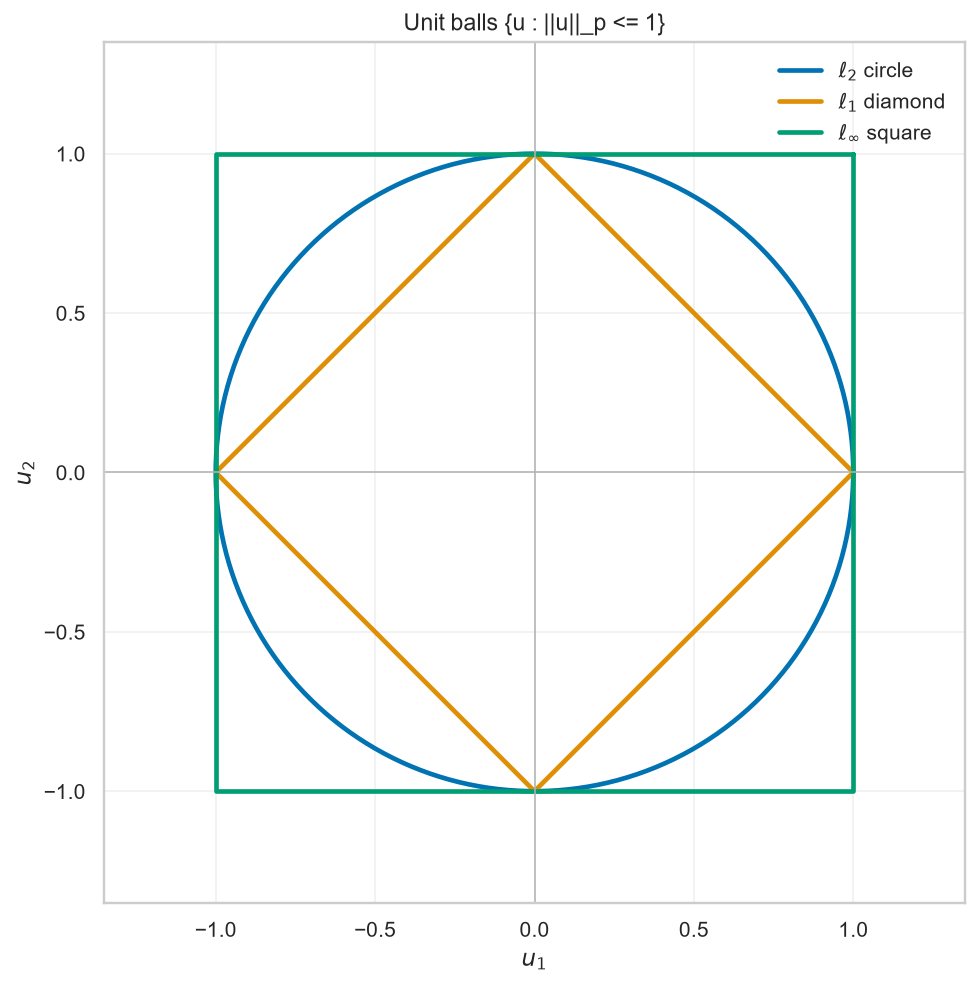

In [8]:
_banner("6.1 · Unit balls")

fig, ax = plt.subplots(figsize=(7.2, 7.2))
theta = np.linspace(0, 2 * np.pi, 400)
# L2 circle
ax.plot(np.cos(theta), np.sin(theta), lw=2.4, label=r"$\ell_2$ circle")
# L1 diamond: |x|+|y|=1
ax.plot([0, 1, 0, -1, 0], [1, 0, -1, 0, 1], lw=2.4, label=r"$\ell_1$ diamond")
# L∞ square: max(|x|,|y|)=1
ax.plot([1, 1, -1, -1, 1], [1, -1, -1, 1, 1], lw=2.4, label=r"$\ell_\infty$ square")
ax.set_aspect("equal")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.axhline(0, color="0.7", lw=0.8)
ax.axvline(0, color="0.7", lw=0.8)
ax.set_xlabel("$u_1$")
ax.set_ylabel("$u_2$")
ax.set_title(r"Unit balls {u : ||u||_p <= 1}")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


### 6.2 Three pairwise heatmaps (scaled Wine subsample)


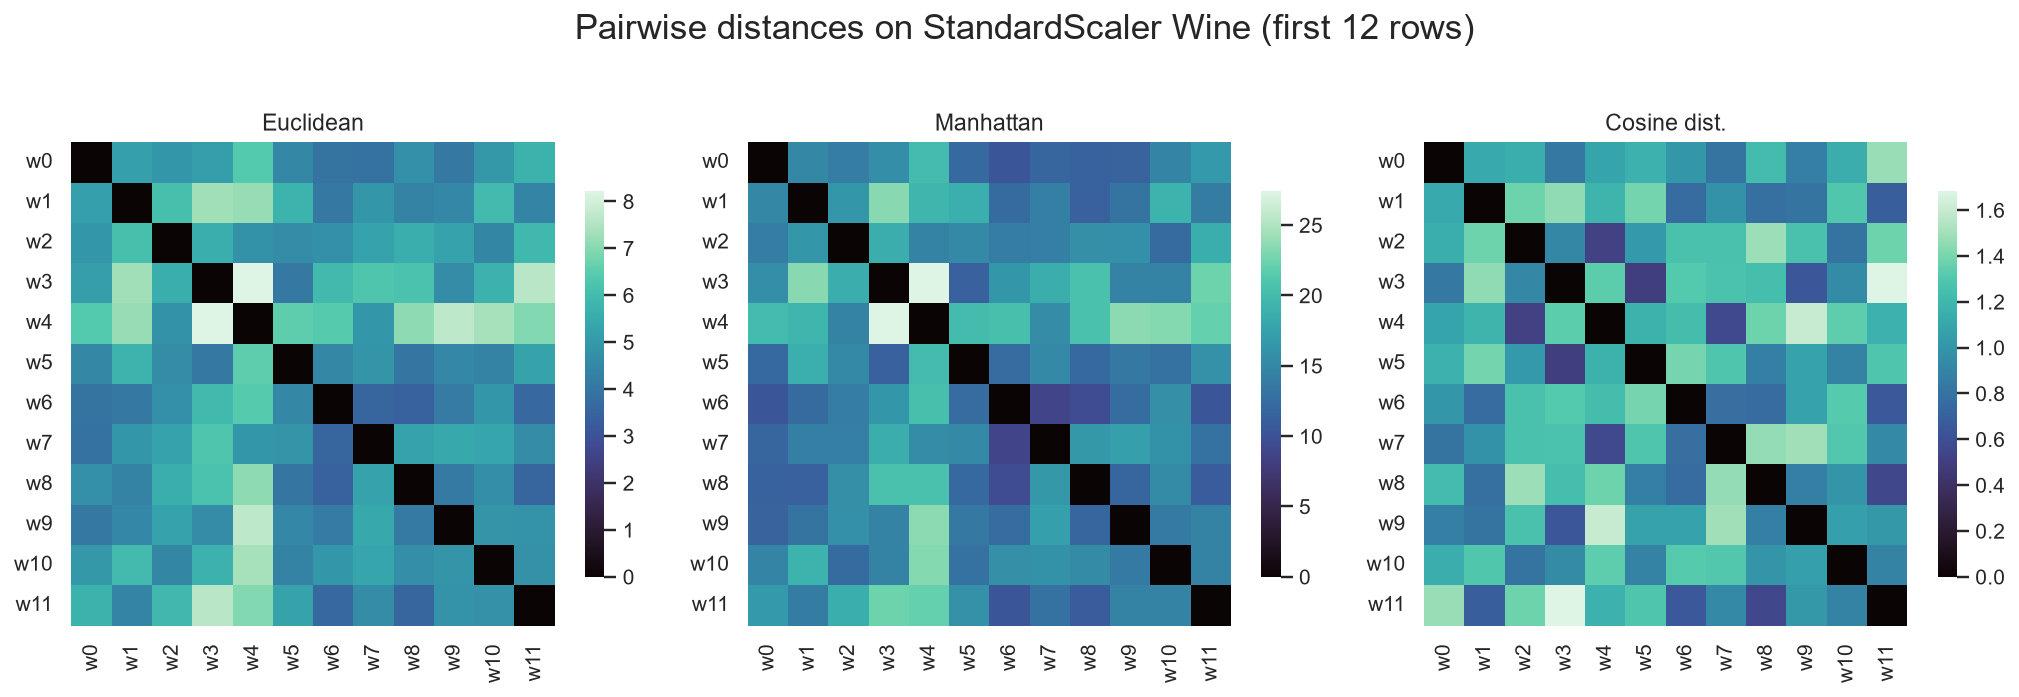

In [9]:
_banner("6.2 · Heatmaps")

n_show = min(12, len(X_wine))
Xs12 = StandardScaler().fit_transform(X_wine[:n_show])
idx = [f"w{i}" for i in range(n_show)]
mats = {
    "Euclidean": pairwise_distances(Xs12, metric="euclidean"),
    "Manhattan": pairwise_distances(Xs12, metric="manhattan"),
    "Cosine dist.": pairwise_distances(Xs12, metric="cosine"),
}

fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.6))
for ax, (name, M) in zip(axes, mats.items()):
    sns.heatmap(
        pd.DataFrame(M, index=idx, columns=idx),
        ax=ax,
        cmap="mako",
        square=True,
        cbar_kws={"shrink": 0.72},
        xticklabels=True,
        yticklabels=True,
    )
    ax.set_title(name)
fig.suptitle("Pairwise distances on StandardScaler Wine (first 12 rows)", y=1.03)
fig.tight_layout()
plt.show()


### 6.3 Distance concentration as dimension grows

For each $d$, sample 200 points in $[0,1]^d$, compute all pairwise Euclidean distances, plot $(d_{\max}-d_{\min})/d_{\min}$.


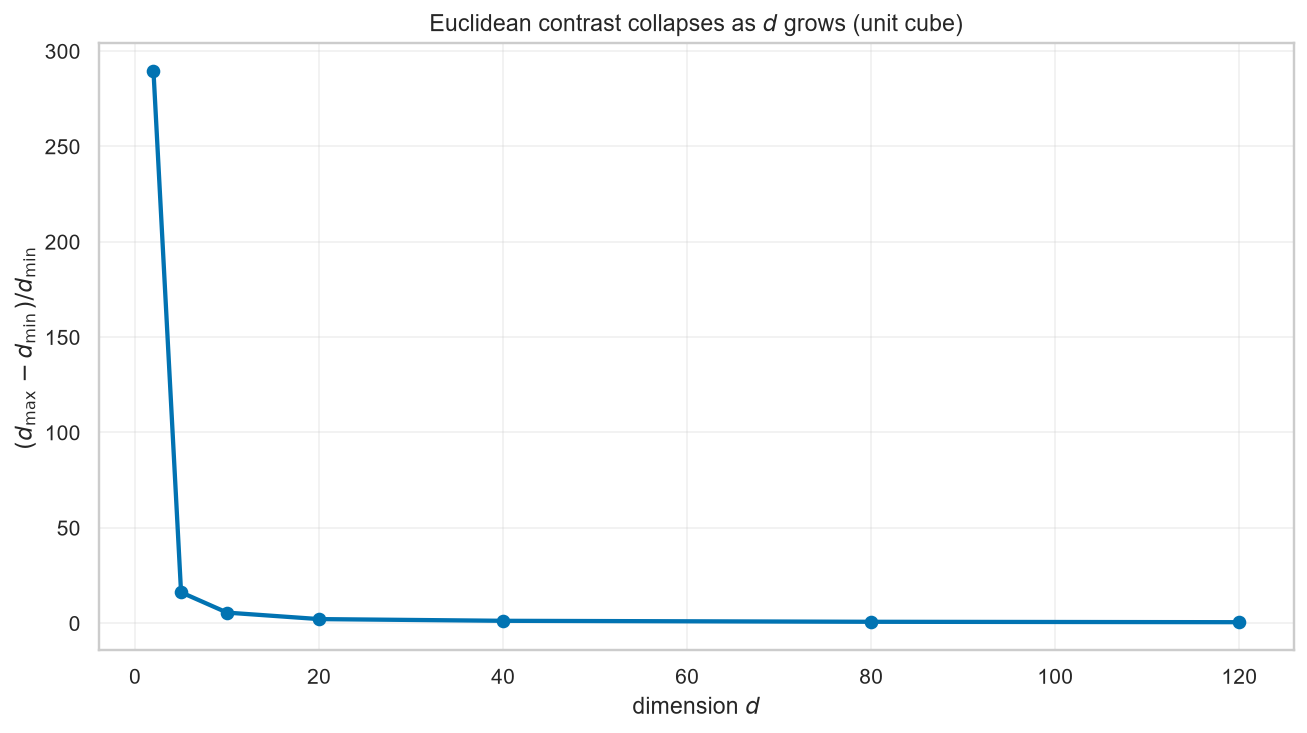

In [10]:
_banner("6.3 · Curse of dimensionality")

rng = np.random.default_rng(SEED)
dims = [2, 5, 10, 20, 40, 80, 120]
contrasts = []
n_pts = 200  # why: enough pairs without a huge n² cost
for d in dims:
    P = rng.random((n_pts, d))  # why: unit cube — a standard concentration demo
    D = pairwise_distances(P, metric="euclidean")
    tri = D[np.triu_indices_from(D, k=1)]  # why: skip the zero diagonal
    contrasts.append((tri.max() - tri.min()) / tri.min())

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.plot(dims, contrasts, marker="o", lw=2.2)
ax.set_xlabel("dimension $d$")
ax.set_ylabel(r"$(d_{\max}-d_{\min})/d_{\min}$")
ax.set_title("Euclidean contrast collapses as $d$ grows (unit cube)")
fig.tight_layout()
plt.show()

_why(
    "When this ratio is tiny, 'nearest' and 'farthest' are almost the same number. "
    "That is why naive k-NN on hundreds of raw features often fails."
)


## 7. Viva-voce (indicative Q&A)

**Q1. Write Euclidean and Manhattan distances in $\mathbb{R}^{d}$.**  
**A.** $d_2=\sqrt{\sum_j(x_j-y_j)^{2}}$, $d_1=\sum_j|x_j-y_j|$.

**Q2. What is Chebyshev distance?**  
**A.** $d_\infty=\max_j|x_j-y_j|=\lim_{p\to\infty}\|x-y\|_p$.

**Q3. State the Minkowski formula.**  
**A.** $d_p=(\sum_j|x_j-y_j|^{p})^{1/p}$ for $p\ge 1$.

**Q4. Sketch the unit balls for $p=1,2,\infty$.**  
**A.** Diamond, circle, axis-aligned square.

**Q5. Define cosine similarity and cosine distance.**  
**A.** $\cos\theta=x^{\top}y/(\|x\|_2\|y\|_2)$; sklearn $d_{\cos}=1-\cos\theta$. Similarity is not a metric.

**Q6. Why does cosine ignore document length?**  
**A.** Scaling a vector by $\alpha>0$ cancels in the fraction. Euclidean $\|\alpha x-x\|_2=|\alpha-1|\|x\|_2$ grows with length.

**Q7. When is Euclidean a bad idea on raw Wine?**  
**A.** When columns have different units/scales (`proline` vs `hue`). Standardise first, or use a scale-free metric.

**Q8. What is distance concentration?**  
**A.** In high $d$, pairwise distances concentrate; $(d_{\max}-d_{\min})/d_{\min}\to 0$ for typical random designs.

**Q9. Is cosine distance a metric?**  
**A.** Not always treated as one; it can violate triangle inequality for some vector triples. It is still a useful dissimilarity.

**Q10. How do you implement pairwise $\ell_2$ without Python loops?**  
**A.** Broadcast `X[:, None, :] - X[None, :, :]` then `sqrt(sum(squares))`, or `cdist` / `pairwise_distances`.

**Q11. `cdist(..., metric="cosine")` vs `cosine_similarity`?**  
**A.** `cdist` cosine is $1-\cos$. `cosine_similarity` returns $\cos\in[-1,1]$. Do not mix them in a heatmap without labelling.

**Q12. Two TF–IDF vectors with $\cos=1$ but large Euclidean distance — interpret.**  
**A.** Same direction (same topic mix), different $\ell_2$ length (document length / total weight). Rank by cosine for retrieval.


## 8. Conclusion

This practical locked in **how to measure nearness**:

1. **CONFIG** — `DATA_PATH`, `FEATURE_COLUMNS`, `SAMPLE_INDEX_A/B`, `DROP_COLUMNS`.
2. **Hand table** — $\ell_1,\ell_2,\ell_\infty$, dot product, norms, cosine, checked against NumPy / SciPy / sklearn.
3. **Geometry** — Minkowski family, unit balls, curse of dimensionality.
4. **Case study** — scaled Wine vs TF–IDF length invariance.
5. **Figures** — unit balls, three heatmaps, contrast-vs-$d$ curve.

**Next practical:** Decision Tree / ID3 — still without touching `extra/`.

### Submission checklist

- [ ] Re-run all cells on `ml-lab-kernel`
- [ ] Paste the two-vector totals ($L_1,L_2,\cos$) in the lab record
- [ ] Record Wine `load_origin` and which two `SAMPLE_INDEX_*` you compared
